In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint,LearningRateScheduler,TensorBoard,EarlyStopping
from wordcloud import WordCloud
%matplotlib inline

In [2]:
%pip install wordcloud

  Using cached pillow-12.2.0-cp312-cp312-macosx_11_0_arm64.whl.metadata (8.8 kB)
  Using cached contourpy-1.3.3-cp312-cp312-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp312-cp312-macosx_10_13_universal2.whl.metadata (118 kB)
  Using cached kiwisolver-1.5.0-cp312-cp312-macosx_11_0_arm64.whl.metadata (5.1 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 17.2 MB/s eta 0:00:00a 0:00:01
Using cached contourpy-1.3.3-cp312-cp312-macosx_11_0_arm64.whl (273 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.63.0-cp312-cp312-macosx_10_13_universal2.whl (2.9 MB)
Using cached kiwisolver-1.5.0-cp312-cp312-macosx_11_0_arm64.whl (64 kB)
Using cached pillow-12.2.0-cp312-cp312-macosx_11_0_arm64.whl (4.7 MB)
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8

In [4]:
INPUT_DIR = os.path.join("..","artifacts","raw_data")
rating_df = pd.read_csv(INPUT_DIR+"/animelist.csv" , low_memory=True,usecols=["user_id","anime_id","rating"])
rating_df.head()

,user_id,anime_id,rating
0,0,67,9
1,0,6702,7
2,0,242,10
3,0,4898,0
4,0,21,10


In [6]:
rating_df.shape

(5000000, 3)

# Data Preprocessing

In [10]:
n_ratings = rating_df["user_id"].value_counts()
rating_df = rating_df[rating_df["user_id"].isin(n_ratings[n_ratings>=400].index)].copy()

In [11]:
min_rating = rating_df["rating"].min()
max_rating = rating_df["rating"].max()
avg_rating = rating_df["rating"].mean()
print(f"Minimum rating: {min_rating}")
print(f"Maximum rating: {max_rating}")
print(f"Average rating: {avg_rating:.2f}")

Minimum rating: 0
Maximum rating: 10
Average rating: 4.12


In [12]:
rating_df["rating"] = rating_df["rating"].apply(lambda x: (x - min_rating)/(max_rating - min_rating)).values.astype(np.float64)

In [13]:
rating_df.head()

,user_id,anime_id,rating
213,2,24833,0.0
214,2,235,1.0
215,2,36721,0.0
216,2,40956,0.0
217,2,31933,0.0


In [14]:
rating_df.duplicated().sum()

0

In [15]:
rating_df.isnull().sum()

user_id     0
anime_id    0
rating      0
dtype: int64

In [17]:
user_ids = rating_df["user_id"].unique().tolist()
user2user_encoded = {x : i for i , x in enumerate(user_ids)}
user2user_decoded = {i : x for i , x in enumerate(user_ids)}
rating_df["user"] = rating_df["user_id"].map(user2user_encoded)

In [18]:
rating_df.head()

,user_id,anime_id,rating,user
213,2,24833,0.0,0
214,2,235,1.0,0
215,2,36721,0.0,0
216,2,40956,0.0,0
217,2,31933,0.0,0


In [19]:
anime_ids = rating_df["anime_id"].unique().tolist()
anime2anime_encoded = {x : i for i , x in enumerate(anime_ids)}
anime2anime_decoded = {i : x for i , x in enumerate(anime_ids)}
rating_df["anime"] = rating_df["anime_id"].map(anime2anime_encoded)

rating_df.head()

,user_id,anime_id,rating,user,anime
213,2,24833,0.0,0,0
214,2,235,1.0,0,1
215,2,36721,0.0,0,2
216,2,40956,0.0,0,3
217,2,31933,0.0,0,4


In [20]:
len(user2user_encoded), len(anime2anime_encoded)

(4203, 17149)

In [22]:
rating_df = rating_df.sample(frac=1,random_state=43).reset_index(drop=True)

In [23]:
rating_df.shape

(3246641, 5)

In [31]:
X = rating_df[["user","anime"]].values
y = rating_df["rating"]

test_size = 100000
train_indices = rating_df.shape[0] - test_size

X_train , X_test , y_train , y_test = (
    X[:train_indices],
    X[train_indices :],
    y[:train_indices],
    y[train_indices:],
)

In [32]:
len(X_train), len(X_test)

(3146641, 100000)

In [33]:
X_train_array = [X_train[: , 0] , X_train[: ,1]]
X_test_array = [X_test[: , 0] , X_test[: ,1]]

# Model Training

In [35]:
def RecommenderNet():
    "Recommender network architecture"
    embedding_size =128
    n_users = len(user2user_encoded)
    n_anime = len(anime2anime_encoded)

    user = keras.layers.Input(name="user",shape=(1,))
    anime = keras.layers.Input(name="anime",shape=(1,))

    user_embedding = keras.layers.Embedding(name="user_embedding", input_dim=n_users, output_dim=embedding_size)(user)
    anime_embedding = keras.layers.Embedding(name="anime_embedding", input_dim=n_anime, output_dim=embedding_size)(anime)

    user_vec = keras.layers.Flatten()(user_embedding)
    anime_vec = keras.layers.Flatten()(anime_embedding)

    x = keras.layers.Concatenate()([user_vec, anime_vec])
    x = keras.layers.Dense(256, activation='relu')(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.Dropout(0.3)(x)
    x = keras.layers.Dense(128, activation='relu')(x)
    x = keras.layers.Dropout(0.3)(x)

    output = keras.layers.Dense(1, activation='sigmoid')(x)

    model = Model(inputs=[user,anime], outputs=output)
    model.compile(loss="binary_crossentropy",metrics=["mae","mse"],optimizer='Adam')

    return model

In [36]:
model = RecommenderNet()
model.summary()

2026-06-14 20:43:30.615141: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3 Pro
2026-06-14 20:43:30.615313: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 18.00 GB
2026-06-14 20:43:30.615345: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 6.00 GB
2026-06-14 20:43:30.615395: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-06-14 20:43:30.615413: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ user (InputLayer)   │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ anime (InputLayer)  │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_embedding      │ (None, 1, 128)    │    537,984 │ user[0][0]        │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ anime_embedding     │ (None, 1, 128)    │  2,195,072 │ anime[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 128)       │          0 │ user_embedding[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 128)       │          0 │ anime_embedding[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 256)       │          0 │ flatten[0][0],    │
│ (Concatenate)       │                   │            │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │     65,792 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256)       │      1,024 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     32,896 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │        129 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,832,897 (10.81 MB)

 Trainable params: 2,832,385 (10.80 MB)

 Non-trainable params: 512 (2.00 KB)

In [37]:
start_lr = 0.00001
min_lr = 0.0001
max_lr = 0.00005
batch_size = 10000

ramup_epochs = 5
sustain_epochs = 0
exp_decay = 0.8

def lrfn(epoch):
    if epoch<ramup_epochs:
        return (max_lr-start_lr)/ramup_epochs*epoch + start_lr
    elif epoch<ramup_epochs+sustain_epochs:
        return max_lr
    else:
        return (max_lr-min_lr) * exp_decay ** (epoch-ramup_epochs-sustain_epochs)+min_lr
    
lr_callback = LearningRateScheduler(lambda epoch:lrfn(epoch) , verbose=0)
checkpoint_filepath = './weights.weights.h5'

model_checkpoint = ModelCheckpoint(filepath=checkpoint_filepath,save_weights_only=True,monitor="val_loss",mode="min",save_best_only=True)

early_stopping = EarlyStopping(patience=3,monitor="val_loss",mode="min",restore_best_weights=True)

In [38]:
history = model.fit(
    x=X_train_array,
    y=y_train,
    batch_size=batch_size,
    epochs=30,
    verbose=1,
    validation_data = (X_test_array,y_test),
    callbacks=[model_checkpoint,lr_callback,early_stopping]
)

Epoch 1/30


2026-06-14 20:45:39.109428: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


315/315 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - loss: 0.8839 - mae: 0.3885 - mse: 0.2158 - val_loss: 0.6819 - val_mae: 0.3580 - val_mse: 0.1498 - learning_rate: 1.0000e-05
Epoch 2/30
315/315 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - loss: 0.7858 - mae: 0.3667 - mse: 0.1870 - val_loss: 0.6567 - val_mae: 0.3412 - val_mse: 0.1377 - learning_rate: 1.8000e-05
Epoch 3/30
315/315 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - loss: 0.7315 - mae: 0.3447 - mse: 0.1662 - val_loss: 0.6167 - val_mae: 0.3058 - val_mse: 0.1201 - learning_rate: 2.6000e-05
Epoch 4/30
315/315 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - loss: 0.6791 - mae: 0.3118 - mse: 0.1441 - val_loss: 0.5800 - val_mae: 0.2699 - val_mse: 0.1053 - learning_rate: 3.4000e-05
Epoch 5/30
315/315 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - loss: 0.6401 - mae: 0.2853 - mse: 0.1281 - val_loss: 0.5629 - val_mae: 0.2526 - val_mse: 0.0987 - learning_rate: 4.2000e-05
Epoch 6/30
315/315 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - loss: 0.6170 - mae: 0.2717 - mse: 0.1193 - val_loss: 0.5552 

In [39]:
model.load_weights(checkpoint_filepath)

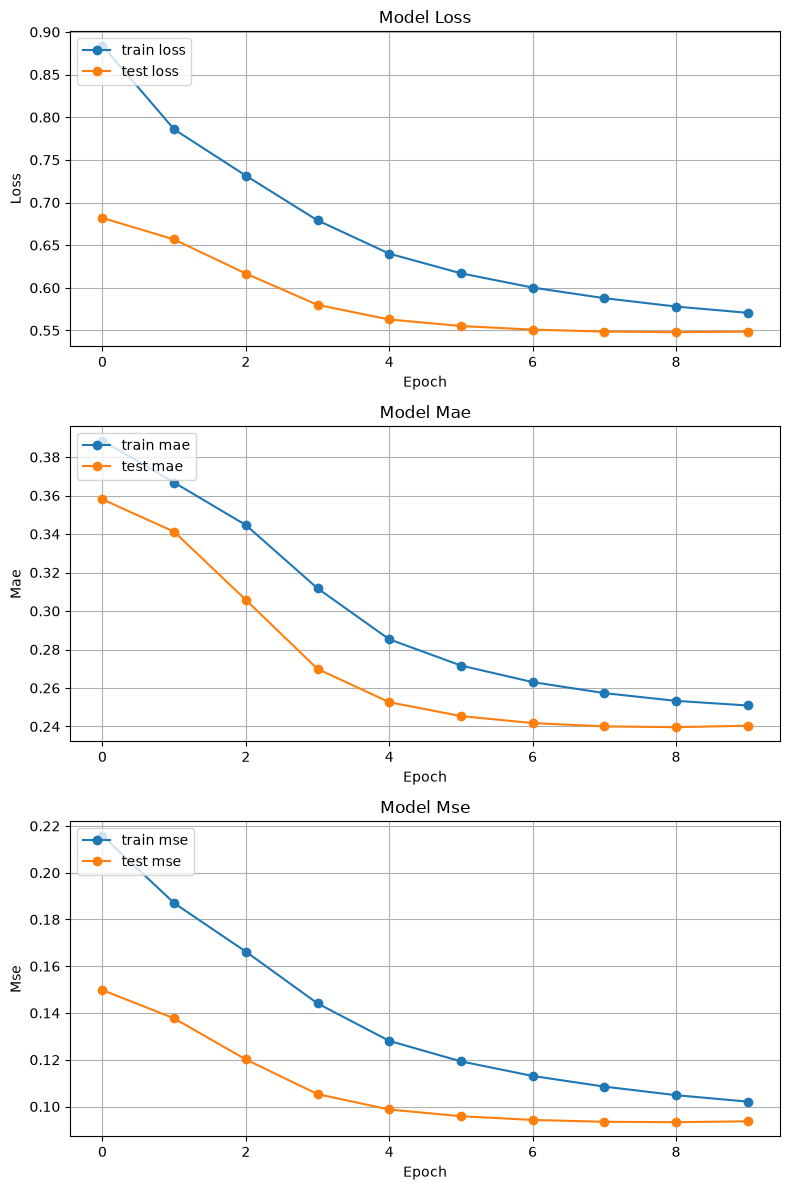

In [40]:
metrics = ["loss", "mae", "mse"]

# Create subplots
fig, axes = plt.subplots(len(metrics), 1, figsize=(8, len(metrics) * 4))

for i, metric in enumerate(metrics):
    ax = axes[i]
    ax.plot(history.history[metric][0:-2], marker="o", label=f"train {metric}")
    ax.plot(history.history[f"val_{metric}"][0:-2], marker="o", label=f"test {metric}")
    ax.set_title(f"Model {metric.capitalize()}")
    ax.set_ylabel(metric.capitalize())
    ax.set_xlabel("Epoch")
    ax.legend(loc="upper left")
    ax.grid(True)

plt.tight_layout()
plt.show()

In [41]:
def extract_weights(layer_name, model):
    weight_layer = model.get_layer(layer_name)
    weights = weight_layer.get_weights()[0]
    weights = weights/np.linalg.norm(weights,axis=1).reshape((-1,1))
    return weights

In [43]:
anime_weights = extract_weights("anime_embedding", model)
anime_weights.shape

(17149, 128)

In [44]:
user_weights = extract_weights("user_embedding", model)
user_weights.shape

(4203, 128)

# Item based recommendation

In [45]:
anime_df = pd.read_csv(INPUT_DIR+"/anime.csv",low_memory=True)
anime_df.head(2)

,MAL_ID,Name,Score,Genres,English name,Japanese name,Type,Episodes,Aired,Premiered,...,Score-10,Score-9,Score-8,Score-7,Score-6,Score-5,Score-4,Score-3,Score-2,Score-1
0,1,Cowboy Bebop,8.78,"Action, Adventure, Comedy, Drama, Sci-Fi, Space",Cowboy Bebop,カウボーイビバップ,TV,26,"Apr 3, 1998 to Apr 24, 1999",Spring 1998,...,229170.0,182126.0,131625.0,62330.0,20688.0,8904.0,3184.0,1357.0,741.0,1580.0
1,5,Cowboy Bebop: Tengoku no Tobira,8.39,"Action, Drama, Mystery, Sci-Fi, Space",Cowboy Bebop:The Movie,カウボーイビバップ 天国の扉,Movie,1,"Sep 1, 2001",Unknown,...,30043.0,49201.0,49505.0,22632.0,5805.0,1877.0,577.0,221.0,109.0,379.0


In [46]:
anime_df = anime_df.replace("Unknown",np.nan)

def getAnimeName(anime_id):
    try:
        name = anime_df[anime_df.anime_id == anime_id].eng_version.values[0]
        if name is np.nan:
            name = anime_df[anime_df.anime_id == anime_id].Name.values[0]
    except:
        print("Error")
    return name

anime_df["anime_id"] = anime_df["MAL_ID"]
anime_df["eng_version"] = anime_df["English name"]
anime_df["eng_version"] = anime_df.anime_id.apply(lambda x:getAnimeName(x))

In [47]:
anime_df.head(2)

,MAL_ID,Name,Score,Genres,English name,Japanese name,Type,Episodes,Aired,Premiered,...,Score-8,Score-7,Score-6,Score-5,Score-4,Score-3,Score-2,Score-1,anime_id,eng_version
0,1,Cowboy Bebop,8.78,"Action, Adventure, Comedy, Drama, Sci-Fi, Space",Cowboy Bebop,カウボーイビバップ,TV,26,"Apr 3, 1998 to Apr 24, 1999",Spring 1998,...,131625.0,62330.0,20688.0,8904.0,3184.0,1357.0,741.0,1580.0,1,Cowboy Bebop
1,5,Cowboy Bebop: Tengoku no Tobira,8.39,"Action, Drama, Mystery, Sci-Fi, Space",Cowboy Bebop:The Movie,カウボーイビバップ 天国の扉,Movie,1,"Sep 1, 2001",NaN,...,49505.0,22632.0,5805.0,1877.0,577.0,221.0,109.0,379.0,5,Cowboy Bebop:The Movie


In [48]:
getAnimeName(6702)

'Fairy Tail'

In [49]:
anime_df = anime_df[["anime_id" , "eng_version","Score","Genres","Episodes","Type","Premiered","Members"]]

In [50]:
def getAnimeFrame(anime,df):
    if isinstance(anime,int):
        return df[df.anime_id == anime]
    if isinstance(anime,str):
        return df[df.eng_version == anime]
    

In [51]:
getAnimeFrame(40028 , anime_df)

,anime_id,eng_version,Score,Genres,Episodes,Type,Premiered,Members
15926,40028,Attack on Titan Final Season,9.17,"Action, Military, Mystery, Super Power, Drama,...",16,TV,Winter 2021,733260


In [52]:
getAnimeFrame("Steins;Gate",anime_df)

,anime_id,eng_version,Score,Genres,Episodes,Type,Premiered,Members
5683,9253,Steins;Gate,9.11,"Thriller, Sci-Fi",24,TV,Spring 2011,1771162


In [53]:
# Reading anime with synopsis
cols = ["MAL_ID","Name","Genres","sypnopsis"]
synopsis_df = pd.read_csv(INPUT_DIR+"/anime_with_synopsis.csv",usecols=cols)
synopsis_df.head()

,MAL_ID,Name,Genres,sypnopsis
0,1,Cowboy Bebop,"Action, Adventure, Comedy, Drama, Sci-Fi, Space","In the year 2071, humanity has colonized sever..."
1,5,Cowboy Bebop: Tengoku no Tobira,"Action, Drama, Mystery, Sci-Fi, Space","other day, another bounty—such is the life of ..."
2,6,Trigun,"Action, Sci-Fi, Adventure, Comedy, Drama, Shounen","Vash the Stampede is the man with a $$60,000,0..."
3,7,Witch Hunter Robin,"Action, Mystery, Police, Supernatural, Drama, ...",ches are individuals with special powers like ...
4,8,Bouken Ou Beet,"Adventure, Fantasy, Shounen, Supernatural",It is the dark century and the people are suff...


In [69]:
def getSynopsis(anime,synopsis_df):
    if isinstance(anime,int):
        if synopsis_df[synopsis_df.MAL_ID == anime].empty:
            return None
        return synopsis_df[synopsis_df.MAL_ID == anime].sypnopsis.values[0]
    if isinstance(anime,str):
        if synopsis_df[synopsis_df.Name == anime].empty:
            return None
        return synopsis_df[synopsis_df.Name == anime].sypnopsis.values[0]
    

In [55]:
getSynopsis(40028 , synopsis_df)

"Gabi Braun and Falco Grice have been training their entire lives to inherit one of the seven titans under Marley's control and aid their nation in eradicating the Eldians on Paradis. However, just as all seems well for the two cadets, their peace is suddenly shaken by the arrival of Eren Yeager and the remaining members of the Survey Corps. Having finally reached the Yeager family basement and learned about the dark history surrounding the titans, the Survey Corps has at long last found the answer they so desperately fought to uncover. With the truth now in their hands, the group set out for the world beyond the walls. In Shingeki no Kyojin: The Final Season , two utterly different worlds collide as each party pursues its own agenda in the long-awaited conclusion to Paradis' fight for freedom."

In [56]:
getSynopsis("Steins;Gate",synopsis_df)

'The self-proclaimed mad scientist Rintarou Okabe rents out a room in a rickety old building in Akihabara, where he indulges himself in his hobby of inventing prospective "future gadgets" with fellow lab members: Mayuri Shiina, his air-headed childhood friend, and Hashida Itaru, a perverted hacker nicknamed "Daru." The three pass the time by tinkering with their most promising contraption yet, a machine dubbed the "Phone Microwave," which performs the strange function of morphing bananas into piles of green gel. Though miraculous in itself, the phenomenon doesn\'t provide anything concrete in Okabe\'s search for a scientific breakthrough; that is, until the lab members are spurred into action by a string of mysterious happenings before stumbling upon an unexpected success—the Phone Microwave can send emails to the past, altering the flow of history. Adapted from the critically acclaimed visual novel by 5pb. and Nitroplus, Steins;Gate takes Okabe through the depths of scientific theory 

In [71]:
def find_similar_animes(name, anime_weights, anime2anime_encoded, anime2anime_decoded, df, synopsis_df, n=10, return_dist=False, neg=False):
    # Get the anime_id for the given name
    index = getAnimeFrame(name, df).anime_id.values[0]
    encoded_index = anime2anime_encoded.get(index)

    if encoded_index is None:
        raise ValueError(f"Encoded index not found for anime ID: {index}")

    weights = anime_weights

    # Compute the similarity distances
    dists = np.dot(weights, weights[encoded_index])  # Ensure weights[encoded_index] is a 1D array
    sorted_dists = np.argsort(dists)

    n = n + 1

    # Select closest or farthest based on 'neg' flag
    if neg:
        closest = sorted_dists[:n]
    else:
        closest = sorted_dists[-n:]

    # Return distances and closest indices if requested
    if return_dist:
        return dists, closest

    # Build the similarity array
    SimilarityArr = []
    for idx in closest:
        decoded_id = anime2anime_decoded.get(idx)
        synopsis = getSynopsis(decoded_id, synopsis_df)
        anime_frame = getAnimeFrame(decoded_id, df)
        anime_name = anime_frame.eng_version.values[0]
        genre = anime_frame.Genres.values[0]
        similarity = dists[idx]

        SimilarityArr.append({
            "anime_id": decoded_id,
            "name": anime_name,
            "similarity": similarity,
            "genre": genre,
            "synopsis": synopsis
        })
       
    # Create a DataFrame with results and sort by similarity
    Frame = pd.DataFrame(SimilarityArr).sort_values(by="similarity", ascending=False)
    return Frame[Frame.anime_id != index].drop(['anime_id'], axis=1)


In [62]:
np.dot(anime_weights, anime_weights[0])

array([ 0.99999994,  0.06754987,  0.07416805, ...,  0.0342491 ,
       -0.05112815,  0.04184328], dtype=float32)

In [61]:
anime_weights.shape

(17149, 128)

In [72]:
find_similar_animes("Naruto", anime_weights, anime2anime_encoded, anime2anime_decoded, anime_df, synopsis_df)

,name,similarity,genre,synopsis
9,I Can't Understand What My Husband Is Saying,0.306272,"Slice of Life, Comedy, Romance, Seinen","Though they couldn't be any more different, lo..."
8,My Hero Academia,0.305748,"Action, Comedy, School, Shounen, Super Power","The appearance of ""quirks,"" newly discovered s..."
7,Death Note,0.298675,"Mystery, Police, Psychological, Supernatural, ...","shinigami, as a god of death, can kill any per..."
6,Sanuki Eiga-sai Opening Eizou,0.297405,"Dementia, Music",Sanuki Film Festival in 2015 and 2016 had open...
5,Fight League:Gear Gadget Generators,0.296264,"Action, Sci-Fi, Mecha",Fight League is a cellphone game from XFLAG th...
4,Interviews With Monster Girls:The Demi-chans' ...,0.295829,"Comedy, Vampire, Fantasy, School, Seinen","During summer break, Tetsuo asks Sakie to join..."
3,Baby Felix,0.291155,"Comedy, Kids",oung Felix the Cat and his baby pals find fun ...
2,Mahou no Chocolate,0.289189,"Drama, Romance",ami-chan has a crush on her school's soccer cl...
1,Inuyashiki:Last Hero,0.281735,"Action, Drama, Psychological, Sci-Fi, Seinen",Ichirou Inuyashiki is a 58-year-old family man...
0,Kokoro wa Hallelujah,0.281607,"Kids, Music","Hallelujah of the heart, the world is filled w..."


# User based recommendation

In [73]:
def find_similar_users(item_input , user_weights , user2user_encoded , user2user_decoded, n=10 , return_dist=False,neg=False):
    try:
        index=item_input
        encoded_index = user2user_encoded.get(index)

        weights = user_weights

        dists = np.dot(weights,weights[encoded_index])
        sorted_dists = np.argsort(dists)

        n=n+1

        if neg:
            closest = sorted_dists[:n]
        else:
            closest = sorted_dists[-n:]
            

        if return_dist:
            return dists,closest
        
        SimilarityArr = []

        for idx in closest:
            similarity = dists[idx]

            if isinstance(item_input,int):
                decoded_id = user2user_decoded.get(idx)
                SimilarityArr.append({
                    "similar_users" : decoded_id,
                    "similarity" : similarity
                })
        similar_users = pd.DataFrame(SimilarityArr).sort_values(by="similarity",ascending=False)
        similar_users = similar_users[similar_users.similar_users != item_input]
        return similar_users
    except Exception as e:
        print("Error Occured",e)

In [75]:
find_similar_users(11880, user_weights , user2user_encoded , user2user_decoded)

,similar_users,similarity
9,6603,0.360324
8,6249,0.328008
7,8505,0.315139
6,15527,0.302663
5,12219,0.302191
4,7135,0.299844
3,6830,0.273146
2,5648,0.272034
1,4940,0.266678
0,10413,0.256291


In [76]:
def showWordCloud(all_genres):
    genres_cloud = WordCloud(width=700,height=400,background_color='white',colormap='gnuplot').generate_from_frequencies(all_genres)
    plt.figure(figsize=(10,8))
    plt.imshow(genres_cloud,interpolation="bilinear")
    plt.axis("off")
    plt.show()


def getFavGenre(frame , plot=False):
    from collections import defaultdict
    
    frame.dropna(inplace=False)
    all_genres = defaultdict(int)

    genres_list = []
    for genres in frame["Genres"]:
        if isinstance(genres,str):
            for genre in genres.split(','):
                genres_list.append(genre)
                all_genres[genre.strip()] += 1

    if plot:
        showWordCloud(all_genres)
    
    return genres_list



In [84]:
def get_user_preferences(user_id , rating_df , anime_df ,plot=False):

    animes_watched_by_user = rating_df[rating_df.user_id == user_id]

    user_rating_percentile = np.percentile(animes_watched_by_user.rating , 75)

    animes_watched_by_user = animes_watched_by_user[animes_watched_by_user.rating >= user_rating_percentile]

    top_animes_watched_by_user = (
        animes_watched_by_user.sort_values(by="rating" , ascending=False).anime_id.values
    )

    anime_df_rows = anime_df[anime_df["anime_id"].isin(top_animes_watched_by_user)]
    anime_df_rows = anime_df_rows[["eng_version","Genres"]]

    if plot:
        getFavGenre(anime_df_rows,plot)

    return anime_df_rows




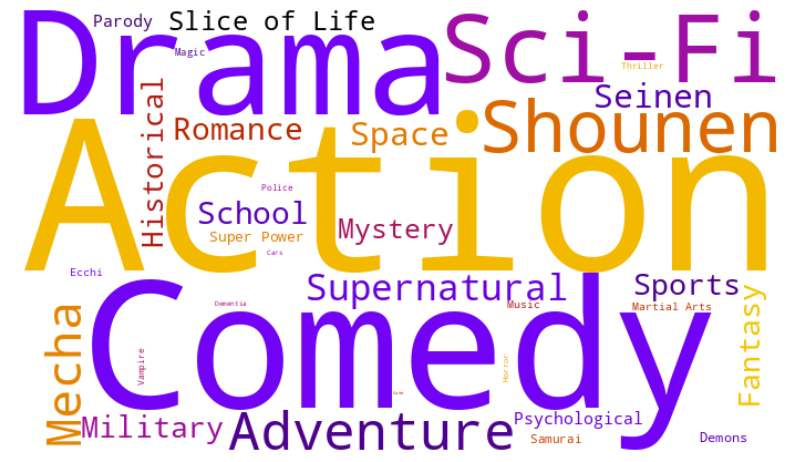

,eng_version,Genres
0,Cowboy Bebop,"Action, Adventure, Comedy, Drama, Sci-Fi, Space"
8,Initial D Fourth Stage,"Action, Cars, Sports, Drama, Seinen"
16,Texhnolyze,"Action, Sci-Fi, Psychological, Drama"
18,Yakitate!! Japan,"Comedy, Shounen"
20,Neon Genesis Evangelion,"Action, Sci-Fi, Dementia, Psychological, Drama..."
...,...,...
11685,Mobile Suit Gundam:Iron-Blooded Orphans 2nd Se...,"Action, Drama, Mecha, Sci-Fi, Space"
11914,My Hero Academia 2,"Action, Comedy, Super Power, School, Shounen"
12242,Gintama Season 5,"Action, Comedy, Historical, Parody, Samurai, S..."
12430,Blood Blockade Battlefront & Beyond,"Action, Comedy, Fantasy, Shounen, Super Power,..."


In [85]:
get_user_preferences(11880 , rating_df, anime_df , plot=True)

In [80]:
anime_df.head(1)

,anime_id,eng_version,Score,Genres,Episodes,Type,Premiered,Members
0,1,Cowboy Bebop,8.78,"Action, Adventure, Comedy, Drama, Sci-Fi, Space",26,TV,Spring 1998,1251960


In [ ]:
def get_user_recommendations(similar_users , user_pref , anime_df , synopsis_df, rating_df, n=10):

    recommended_animes = []
    anime_list = []

    for user_id in similar_users.similar_users.values:
        pref_list = get_user_preferences(user_id, rating_df, anime_df)

        pref_list = pref_list[~pref_list.eng_version.isin(user_pref.eng_version.values)]

        if not pref_list.empty:
            anime_list.append(pref_list.eng_version.values)

    if anime_list:
            anime_list = pd.DataFrame(anime_list)
            
            sorted_list = pd.DataFrame(pd.Series(anime_list.values.ravel()).value_counts()).head(n)

            for i,anime_name in enumerate(sorted_list.index):
                n_user_pref = sorted_list[sorted_list.index == anime_name].values[0][0]

                if isinstance(anime_name,str):
                    frame = getAnimeFrame(anime_name, anime_df)
                    anime_id = frame.anime_id.values[0]
                    genre = frame.Genres.values[0]
                    synopsis = getSynopsis(int(anime_id),synopsis_df)

                    recommended_animes.append({
                        "n" : n_user_pref,
                        "anime_name" : anime_name,
                        "Genres" : genre,
                        "Synopsis": synopsis
                    })
    return pd.DataFrame(recommended_animes).head(n)



    

In [88]:
similar_users =find_similar_users(11880,user_weights,user2user_encoded,user2user_decoded)
user_pref = get_user_preferences(11880 , rating_df, anime_df , plot=False)
get_user_recommendations(similar_users,user_pref,anime_df, synopsis_df,rating_df)

,n,anime_name,Genres,Synopsis
0,9,Attack on Titan,"Action, Military, Mystery, Super Power, Drama,...","Centuries ago, mankind was slaughtered to near..."
1,9,Aldnoah.Zero,"Action, Military, Sci-Fi, Mecha",The discovery of a hypergate on the Moon once ...
2,8,Death Note,"Mystery, Police, Psychological, Supernatural, ...","shinigami, as a god of death, can kill any per..."
3,8,Code Geass:Lelouch of the Rebellion,"Action, Military, Sci-Fi, Super Power, Drama, ...","In the year 2010, the Holy Empire of Britannia..."
4,8,Code Geass:Lelouch of the Rebellion R2,"Action, Military, Sci-Fi, Super Power, Drama, ...","One year has passed since the Black Rebellion,..."
5,8,Toradora!,"Slice of Life, Comedy, Romance, School",uuji Takasu is a gentle high school student wi...
6,8,Re:ZERO -Starting Life in Another World-,"Psychological, Drama, Thriller, Fantasy",hen Subaru Natsuki leaves the convenience stor...
7,8,Made in Abyss,"Sci-Fi, Adventure, Mystery, Drama, Fantasy",The Abyss—a gaping chasm stretching down into ...
8,8,Nisekoi:False Love,"Harem, Comedy, Romance, School, Shounen","aku Ichijou, a first-year student at Bonyari H..."
9,7,Angel Beats!,"Action, Comedy, Drama, School, Supernatural",Otonashi awakens only to learn he is dead. A r...


# Hybrid Recommendation

In [91]:
def hybrid_recommendation(user_id , user_score=0.5, content_score =0.5):

    ## User Recommndation

    similar_users =find_similar_users(user_id, user_weights, user2user_encoded, user2user_decoded)
    user_pref = get_user_preferences(user_id , rating_df, anime_df)
    user_recommended_animes =get_user_recommendations(similar_users,user_pref,anime_df, synopsis_df,rating_df)
    

    user_recommended_anime_list = user_recommended_animes["anime_name"].tolist()

    #### Content recommendation
    content_recommended_animes = []

    for anime in user_recommended_anime_list:
        similar_animes = find_similar_animes(anime, anime_weights, anime2anime_encoded, anime2anime_decoded, anime_df, synopsis_df)

        if similar_animes is not None and not similar_animes.empty:
            content_recommended_animes.extend(similar_animes["name"].tolist())
        else:
            print(f"No similar anime found {anime}")
    
    combined_scores = {}

    for anime in user_recommended_anime_list:
        combined_scores[anime] = combined_scores.get(anime,0) + user_score

    for anime in content_recommended_animes:
        combined_scores[anime] = combined_scores.get(anime,0) + content_score  

    sorted_animes = sorted(combined_scores.items() , key=lambda x:x[1] , reverse=True)

    return [anime for anime , score in sorted_animes[:10]] 



In [99]:
hybrid_recommendation(313)

['Attack on Titan',
 'Elfen Lied',
 'One Punch Man',
 'Toradora!',
 'Fullmetal Alchemist:Brotherhood',
 'Parasyte -the maxim-',
 'The Testament of Sister New Devil',
 'Clannad',
 'Clannad ~After Story~',
 'Sword Art Online']

In [98]:
anime_df[anime_df.anime_id==313]

,anime_id,eng_version,Score,Genres,Episodes,Type,Premiered,Members
289,313,Aim for the Ace! (1979),6.83,"Sports, Drama, Romance, School, Shoujo",1,Movie,NaN,2981


In [108]:
synopsis_df[synopsis_df.MAL_ID==313].sypnopsis.values[0]

'High school freshman Hiromi joins the tennis club because of her admiration for Ryuzaki. Ryuzaki is a senior, who\'s the best tennis player on the team and also nicknamed "Ochoufujin", ("Madame Butterfly"), because of her elegance on the tennis court. However, the new coach, Jin Munakata, wants the inexperienced Hiromi to play in a forthcoming tournament. Due to this, Hiromi considers quitting tennis for good but, in the depth of her soul, she soon realizes that she loves tennis after all. She returns to the club and, under Munakata\'s coaching, her talent starts to bloom. In the end, Hiromi develops a strong emotional bond with her coach, not knowing that Munakata is risking his life because of a chronic illness. (Source: AnimeNfo)'